<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter4_Basic_Neural_Network1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Practice: Image Classification with CNN**

In [ ]:
# 1. Data preparation
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    transform=transform,
    download=True
)

subset = torch.utils.data.Subset(train_dataset, range(5000))
loader = DataLoader(subset, batch_size=32, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 31.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [ ]:
# Data preparation
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='data',
    train=True
    transform=transform,
    download=True,
)

subset = torch.utils.data.Subset(train_dataset, range(5000))
loader = DataLoader(subset, batch_size=32, shuffle=True)


In [ ]:
# 2. CNN architecture

import torch.nn as nn

class SmallCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # -> (B, 8, 28, 28)
    self.pool = nn.MaxPool2d(2, 2)                           # -> (B, 8, 14, 14)
    self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # -> (B, 16, 14, 14)
    self.fc = nn.Linear(16*14*14, 10)

  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = self.pool(x)
    x = torch.relu(self.conv2(x))
    x = x.view(x.size(0), -1)
    x = self.fc(x)
    return x

model = SmallCNN()

In [ ]:
# CNN architecture
import torch.nn as nn

class SmallCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
    self.fc = nn.Linear(16 * 14 * 14, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = torch.relu(x)
    x = x.view(x.size(0), -1)
    output = self.fc(x)
    return output

model = SmallCNN()


In [ ]:
# 3. Loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 4. Training loop
num_epochs = 3

for epoch in range(num_epochs):
  running_loss = 0.0

  for images, labels in loader:
    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 114.6163
Epoch 2, Loss: 41.9152
Epoch 3, Loss: 27.3910


In [ ]:
# Training loop
num_epochs = 3

for epoch in range(num_epochs):
  running_loss = 0.0

  for images, labels in loader:
    optimizer.zero_grad()

    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()


  print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 18.6572
Epoch 2, Loss: 13.4667
Epoch 3, Loss: 9.0184


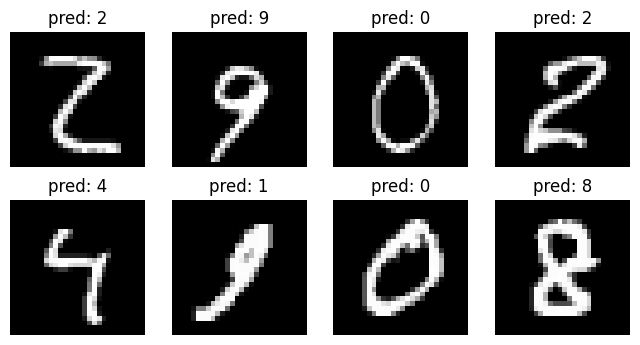

In [ ]:
# 5. Visualization
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
  sample_images, sample_labels = next(iter(loader))
  preds = model(sample_images).argmax(dim=1)

plt.figure(figsize=(8,4))
for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(sample_images[i].squeeze(), cmap='gray')
  plt.title(f"pred: {preds[i].item()}")
  plt.axis('off')

plt.show()

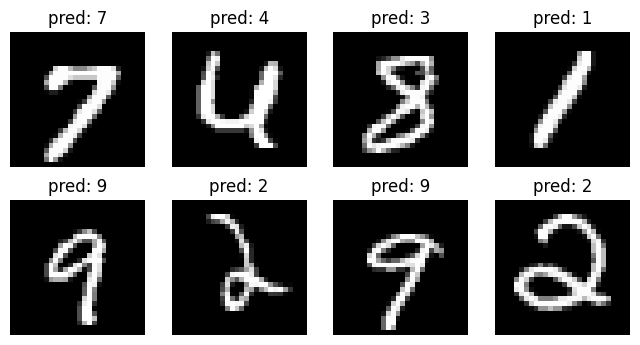

In [ ]:
# Visualization
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
  sample_images, sample_labels = next(iter(loader))
  preds = model(sample_images).argmax(dim=1)

plt.figure(figsize=(8, 4))
for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(sample_images[i].squeeze(), cmap='gray')
  plt.title(f"pred: {preds[i].item()}")
  plt.axis('off')
plt.show()